# Diabetes Risk Prediction

# 04 - CatBoost Model Development

## Objectives

This notebook develops a CatBoost classification model for diabetes risk prediction.

The workflow includes:

- Loading the processed dataset
- Preparing predictors and target
- Creating reproducible train/test splits
- Hyperparameter optimisation using Optuna
- Training the final CatBoost model
- Evaluating predictive performance
- Saving all modelling artefacts for downstream interpretation

## Input

data/processed/diabetes_processed.parquet

## Outputs

models/catboost/

results/model_performance/

figures/catboost/

In [1]:
# ===============================================================
# Import Libraries
# ===============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from catboost import CatBoostClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

c:\Users\saifu\anaconda3\envs\diabetes-ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===============================================================
# Project Configuration
# ===============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR = PROJECT_ROOT / "figures"

CATBOOST_RESULTS_DIR = RESULTS_DIR / "catboost"

CATBOOST_FIGURES_DIR = FIGURES_DIR / "catboost"

CATBOOST_MODEL_DIR = MODELS_DIR / "catboost"

for directory in [

    RESULTS_DIR,

    MODELS_DIR,

    FIGURES_DIR,

    CATBOOST_RESULTS_DIR,

    CATBOOST_FIGURES_DIR,

    CATBOOST_MODEL_DIR

]:

    directory.mkdir(

        parents=True,

        exist_ok=True

    )

In [3]:
# ===============================================================
# Publication Style
# ===============================================================

sns.set_theme(

    style="whitegrid"

)

plt.rcParams.update({

    "figure.dpi":300,

    "savefig.dpi":300,

    "font.family":"Arial",

    "axes.titlesize":18,

    "axes.labelsize":14,

    "xtick.labelsize":12,

    "ytick.labelsize":12

})

diabetes_palette = {

    "0":"#4C72B0",

    "1":"#C44E52"

}

In [4]:
# ===============================================================
# Load Processed Dataset
# ===============================================================

processed_file = (

    PROCESSED_DIR

    / "diabetes_processed.parquet"

)

df = pd.read_parquet(

    processed_file

)

print("="*70)

print("Processed Dataset Loaded")

print("="*70)

print(df.shape)

display(df.head())

Processed Dataset Loaded
(229474, 25)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,BMI_cat,MentHlth_cat,PhysHlth_cat
0,1,1,1,40,1,0,0,0,0,1,...,15,1,0,9,4,3,0,Obese,11-20 days,11-20 days
1,0,0,0,25,1,0,0,1,0,0,...,0,0,0,7,6,1,0,Normal weight,0 days,0 days
2,1,1,1,28,0,0,0,0,1,0,...,30,1,0,9,4,8,0,Overweight,21-30 days,21-30 days
3,1,0,1,27,0,0,0,1,1,1,...,0,0,0,11,3,6,0,Overweight,0 days,0 days
4,1,1,1,24,0,0,0,1,1,1,...,0,0,0,11,5,4,0,Normal weight,1-10 days,0 days


In [5]:
# ===============================================================
# Verify Dataset
# ===============================================================

print("="*70)

print("Dataset Information")

print("="*70)

df.info()

print()

print("="*70)

print("Target Distribution")

print("="*70)

display(

    df["Diabetes_binary"]

    .value_counts()

    .sort_index()

)

print()

print(df["Diabetes_binary"].cat.categories)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229474 entries, 0 to 229473
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   HighBP                229474 non-null  category
 1   HighChol              229474 non-null  category
 2   CholCheck             229474 non-null  category
 3   BMI                   229474 non-null  int64   
 4   Smoker                229474 non-null  category
 5   Stroke                229474 non-null  category
 6   HeartDiseaseorAttack  229474 non-null  category
 7   PhysActivity          229474 non-null  category
 8   Fruits                229474 non-null  category
 9   Veggies               229474 non-null  category
 10  HvyAlcoholConsump     229474 non-null  category
 11  AnyHealthcare         229474 non-null  category
 12  NoDocbcCost           229474 non-null  category
 13  GenHlth               229474 non-null  category
 14  MentHlth        

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64


Index(['0', '1'], dtype='object')


In [6]:
# ===============================================================
# Define Predictors and Target
# ===============================================================

target = "Diabetes_binary"

drop_features = [

    "BMI",

    "MentHlth",

    "PhysHlth"

]

X = (

    df

    .drop(

        columns=[

            target,

            *drop_features

        ]

    )

    .copy()

)

# CatBoost accepts categorical features,
# but convert target back to integers.

y = (

    df[target]

    .astype(int)

)

print(f"Observations : {X.shape[0]}")

print(f"Predictors   : {X.shape[1]}")

Observations : 229474
Predictors   : 21


In [7]:
# ===============================================================
# Identify Categorical Variables
# ===============================================================

cat_features = (

    X

    .select_dtypes(

        include=[

            "category",

            "object"

        ]

    )

    .columns

    .tolist()

)

print("="*70)

print("Categorical Features")

print("="*70)

print(cat_features)

print()

print(f"{len(cat_features)} categorical predictors")

Categorical Features
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_cat', 'MentHlth_cat', 'PhysHlth_cat']

21 categorical predictors


In [8]:
# ===============================================================
# Train-Test Split
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("="*70)

print("Train/Test Split")

print("="*70)

print(f"Training : {X_train.shape}")

print(f"Testing  : {X_test.shape}")

Train/Test Split
Training : (183579, 21)
Testing  : (45895, 21)


In [9]:
# ===============================================================
# Save Train/Test Split
# ===============================================================

split_indices = {

    "train_index":X_train.index.tolist(),

    "test_index":X_test.index.tolist()

}

with open(

    CATBOOST_RESULTS_DIR /

    "train_test_split.json",

    "w"

) as f:

    json.dump(

        split_indices,

        f,

        indent=4

    )

print("Train/test split saved.")

Train/test split saved.


In [10]:
# ===============================================================
# Cross Validation Strategy
# ===============================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

print("5-Fold Stratified Cross Validation Initialised")

5-Fold Stratified Cross Validation Initialised


In [11]:
# ===============================================================
# Optuna Objective Function
# ===============================================================

def objective(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            300,
            1500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30,
            log=True
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            10
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            10
        ),

        "loss_function": "Logloss",

        "eval_metric": "AUC",

        "random_seed": 42,

        "verbose": False

    }

    auc_scores = []

    for train_index, valid_index in cv.split(

        X_train,

        y_train

    ):

        X_tr = X_train.iloc[train_index]

        X_val = X_train.iloc[valid_index]

        y_tr = y_train.iloc[train_index]

        y_val = y_train.iloc[valid_index]

        model = CatBoostClassifier(

            **params,

            auto_class_weights="Balanced"

        )

        model.fit(

            X_tr,

            y_tr,

            cat_features=cat_features,

            eval_set=(X_val, y_val),

            early_stopping_rounds=50,

            use_best_model=True,

            verbose=False

        )

        y_prob = model.predict_proba(

            X_val

        )[:,1]

        auc_scores.append(

            roc_auc_score(

                y_val,

                y_prob

            )

        )

    return np.mean(auc_scores)

In [12]:
# ===============================================================
# Hyperparameter Optimisation (2 trials for demonstration)
# ===============================================================

study = optuna.create_study(

    direction="maximize",

    study_name="CatBoost_Diabetes"

)

study.optimize(

    objective,

    n_trials=2,

    show_progress_bar=True

)

[I 2026-07-17 11:40:45,367] A new study created in memory with name: CatBoost_Diabetes
Best trial: 0. Best value: 0.811397:  50%|█████     | 1/2 [03:35<03:35, 215.22s/it]

[I 2026-07-17 11:44:20,588] Trial 0 finished with value: 0.8113973797412118 and parameters: {'iterations': 1303, 'learning_rate': 0.24226709639082925, 'depth': 10, 'l2_leaf_reg': 7.464719604906161, 'bagging_temperature': 5.4191233375004675, 'random_strength': 9.90096797291398}. Best is trial 0 with value: 0.8113973797412118.


Best trial: 0. Best value: 0.811397: 100%|██████████| 2/2 [07:29<00:00, 224.51s/it]

[I 2026-07-17 11:48:14,373] Trial 1 finished with value: 0.8108543837634494 and parameters: {'iterations': 737, 'learning_rate': 0.1256169898812202, 'depth': 10, 'l2_leaf_reg': 2.8438317268215867, 'bagging_temperature': 5.0135298368453025, 'random_strength': 0.13046178194221492}. Best is trial 0 with value: 0.8113973797412118.


In [13]:
# ===============================================================
# Best Cross Validation Performance
# ===============================================================

print("="*70)

print("Best Cross-Validated ROC-AUC")

print("="*70)

print(f"{study.best_value:.4f}")

print()

print("="*70)

print("Best Hyperparameters")

print("="*70)

for parameter,value in study.best_params.items():

    print(f"{parameter:<30}{value}")

Best Cross-Validated ROC-AUC
0.8114

Best Hyperparameters
iterations                    1303
learning_rate                 0.24226709639082925
depth                         10
l2_leaf_reg                   7.464719604906161
bagging_temperature           5.4191233375004675
random_strength               9.90096797291398


In [14]:
# ===============================================================
# Save Best Hyperparameters
# ===============================================================

best_params = study.best_params.copy()

best_params["loss_function"] = "Logloss"

best_params["eval_metric"] = "AUC"

best_params["random_seed"] = 42

best_params["verbose"] = 100

parameter_file = (

    CATBOOST_RESULTS_DIR /

    "best_parameters.json"

)

with open(

    parameter_file,

    "w"

) as file:

    json.dump(

        best_params,

        file,

        indent=4

    )

print(parameter_file)

c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\results\catboost\best_parameters.json


In [15]:
# ===============================================================
# Save Optuna Trials
# ===============================================================

study.trials_dataframe().to_csv(

    CATBOOST_RESULTS_DIR /

    "optuna_trials.csv",

    index=False

)

In [16]:
# ===============================================================
# Train Final CatBoost Model
# ===============================================================

cat_model = CatBoostClassifier(

    **best_params,

    auto_class_weights="Balanced"

)

cat_model.fit(

    X_train,

    y_train,

    cat_features=cat_features,

    verbose=100

)

print("Model training completed.")

0:	total: 453ms	remaining: 9m 50s
100:	total: 48s	remaining: 9m 30s
200:	total: 2m 25s	remaining: 13m 15s
300:	total: 4m 23s	remaining: 14m 38s
400:	total: 6m 19s	remaining: 14m 13s
500:	total: 8m 31s	remaining: 13m 39s
600:	total: 9m 50s	remaining: 11m 29s
700:	total: 10m 41s	remaining: 9m 10s
800:	total: 11m 36s	remaining: 7m 16s
900:	total: 12m 32s	remaining: 5m 35s
1000:	total: 13m 33s	remaining: 4m 5s
1100:	total: 14m 39s	remaining: 2m 41s
1200:	total: 15m 42s	remaining: 1m 20s
1300:	total: 16m 48s	remaining: 1.55s
1302:	total: 16m 50s	remaining: 0us
Model training completed.


In [17]:
# ===============================================================
# Save Final Model
# ===============================================================

model_file = (

    CATBOOST_MODEL_DIR /

    "catboost_model.cbm"

)

cat_model.save_model(

    model_file

)

print(model_file)

c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\models\catboost\catboost_model.cbm


In [18]:
# ===============================================================
# Predict Test Dataset
# ===============================================================

y_pred = cat_model.predict(

    X_test

)

y_prob = cat_model.predict_proba(

    X_test

)[:,1]

prediction_df = pd.DataFrame({

    "Observed": y_test,

    "Predicted": y_pred,

    "Probability": y_prob

})

prediction_df.to_csv(

    CATBOOST_RESULTS_DIR /

    "predictions.csv",

    index=False

)

display(

    prediction_df.head()

)

,Observed,Predicted,Probability
205102,0,1,0.539462
128952,0,0,0.000056
197039,0,0,0.015760
90334,0,0,0.020282
215866,0,0,0.000706


In [19]:
# ===============================================================
# Model Performance
# ===============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

metrics = {

    "Accuracy": accuracy_score(y_test, y_pred),

    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1 Score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_prob),

    "Matthews Correlation": matthews_corrcoef(y_test, y_pred),

    "Cohen Kappa": cohen_kappa_score(y_test, y_pred),

    "Brier Score": brier_score_loss(y_test, y_prob)

}

metrics_df = pd.DataFrame(

    metrics,

    index=["CatBoost"]

).T

display(metrics_df)

metrics_df.to_csv(

    CATBOOST_RESULTS_DIR /

    "model_metrics.csv"

)

,CatBoost
Accuracy,0.783440
Balanced Accuracy,0.666928
Precision,0.352912
Recall,0.499074
F1 Score,0.413455
ROC AUC,0.768291
Matthews Correlation,0.291868
Cohen Kappa,0.285422
Brier Score,0.146959


In [20]:
# ===============================================================
# Classification Report
# ===============================================================

report = classification_report(

    y_test,

    y_pred

)

print(report)

with open(

    CATBOOST_RESULTS_DIR /

    "classification_report.txt",

    "w"

) as f:

    f.write(report)

              precision    recall  f1-score   support

           0       0.90      0.83      0.87     38876
           1       0.35      0.50      0.41      7019

    accuracy                           0.78     45895
   macro avg       0.63      0.67      0.64     45895
weighted avg       0.82      0.78      0.80     45895



NameError: name 'save_figure' is not defined

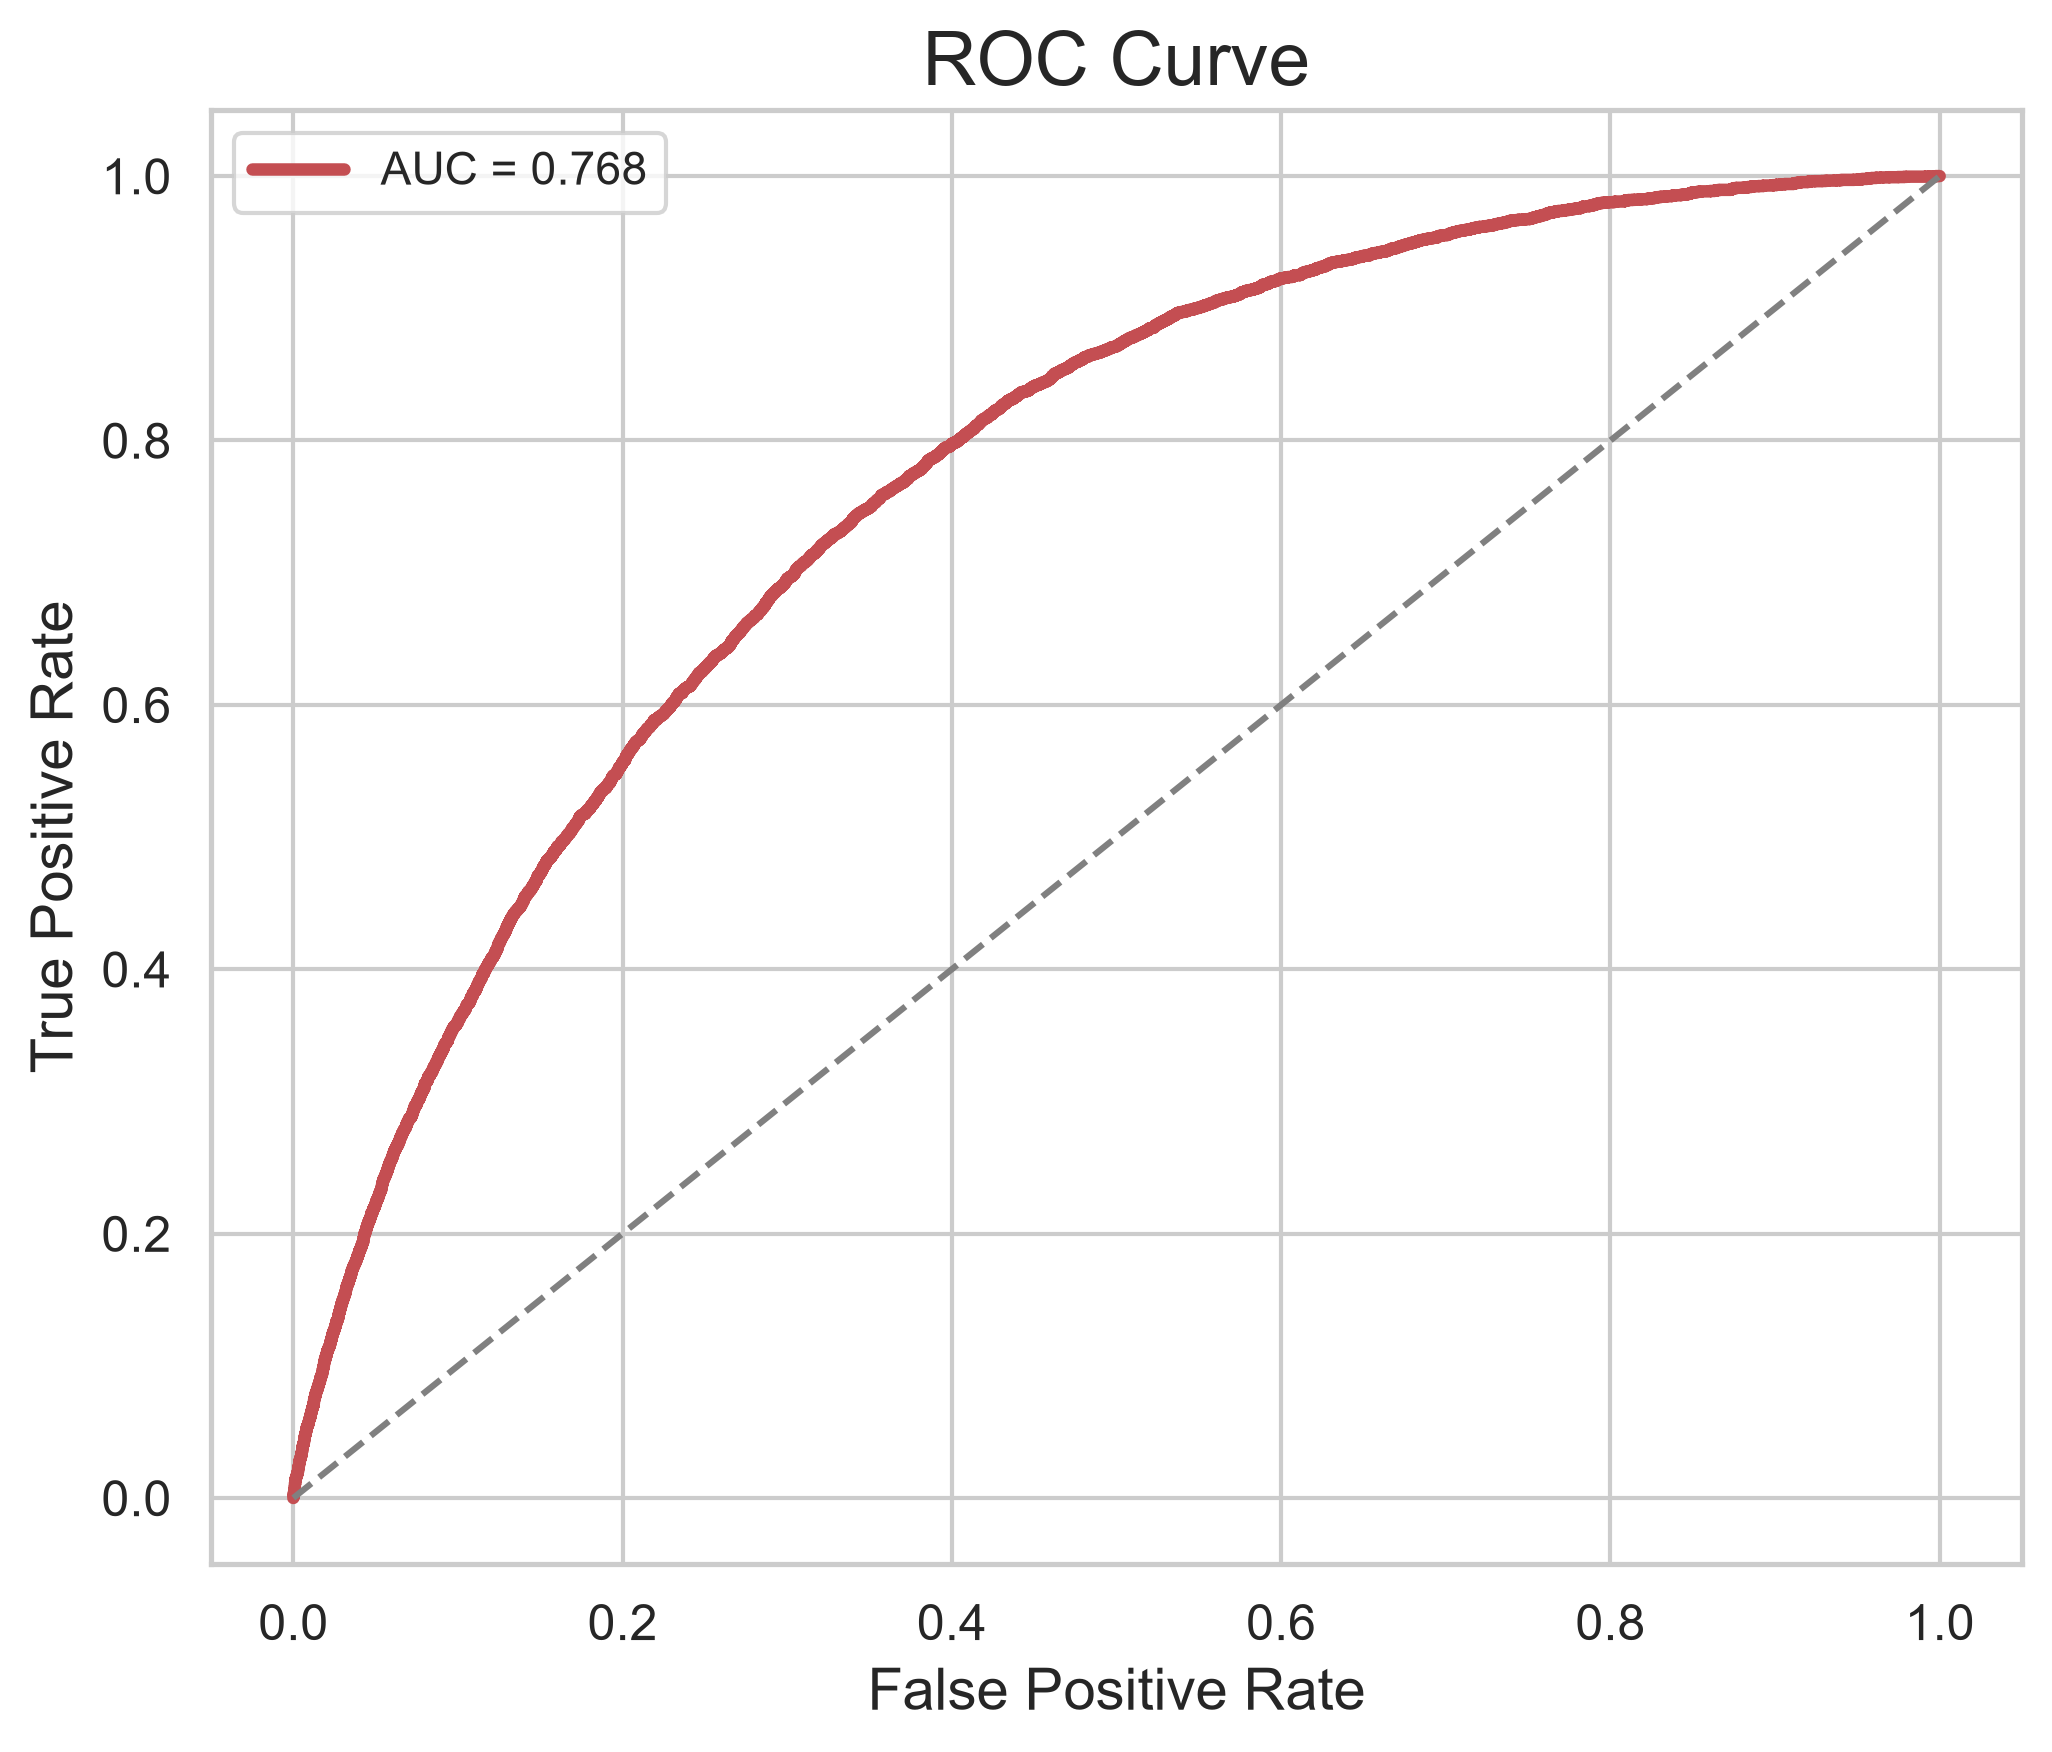

In [21]:
# ===============================================================
# ROC Curve
# ===============================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(

    y_test,

    y_prob

)

fig, ax = plt.subplots(

    figsize=(7,6)

)

ax.plot(

    fpr,

    tpr,

    linewidth=3,

    color="#C44E52",

    label=f"AUC = {metrics['ROC AUC']:.3f}"

)

ax.plot(

    [0,1],

    [0,1],

    "--",

    color="grey"

)

ax.set_xlabel("False Positive Rate")

ax.set_ylabel("True Positive Rate")

ax.set_title("ROC Curve")

ax.legend()

plt.tight_layout()

save_figure(

    fig,

    CATBOOST_FIGURES_DIR,

    "roc_curve.png"

)

plt.show()

NameError: name 'save_figure' is not defined

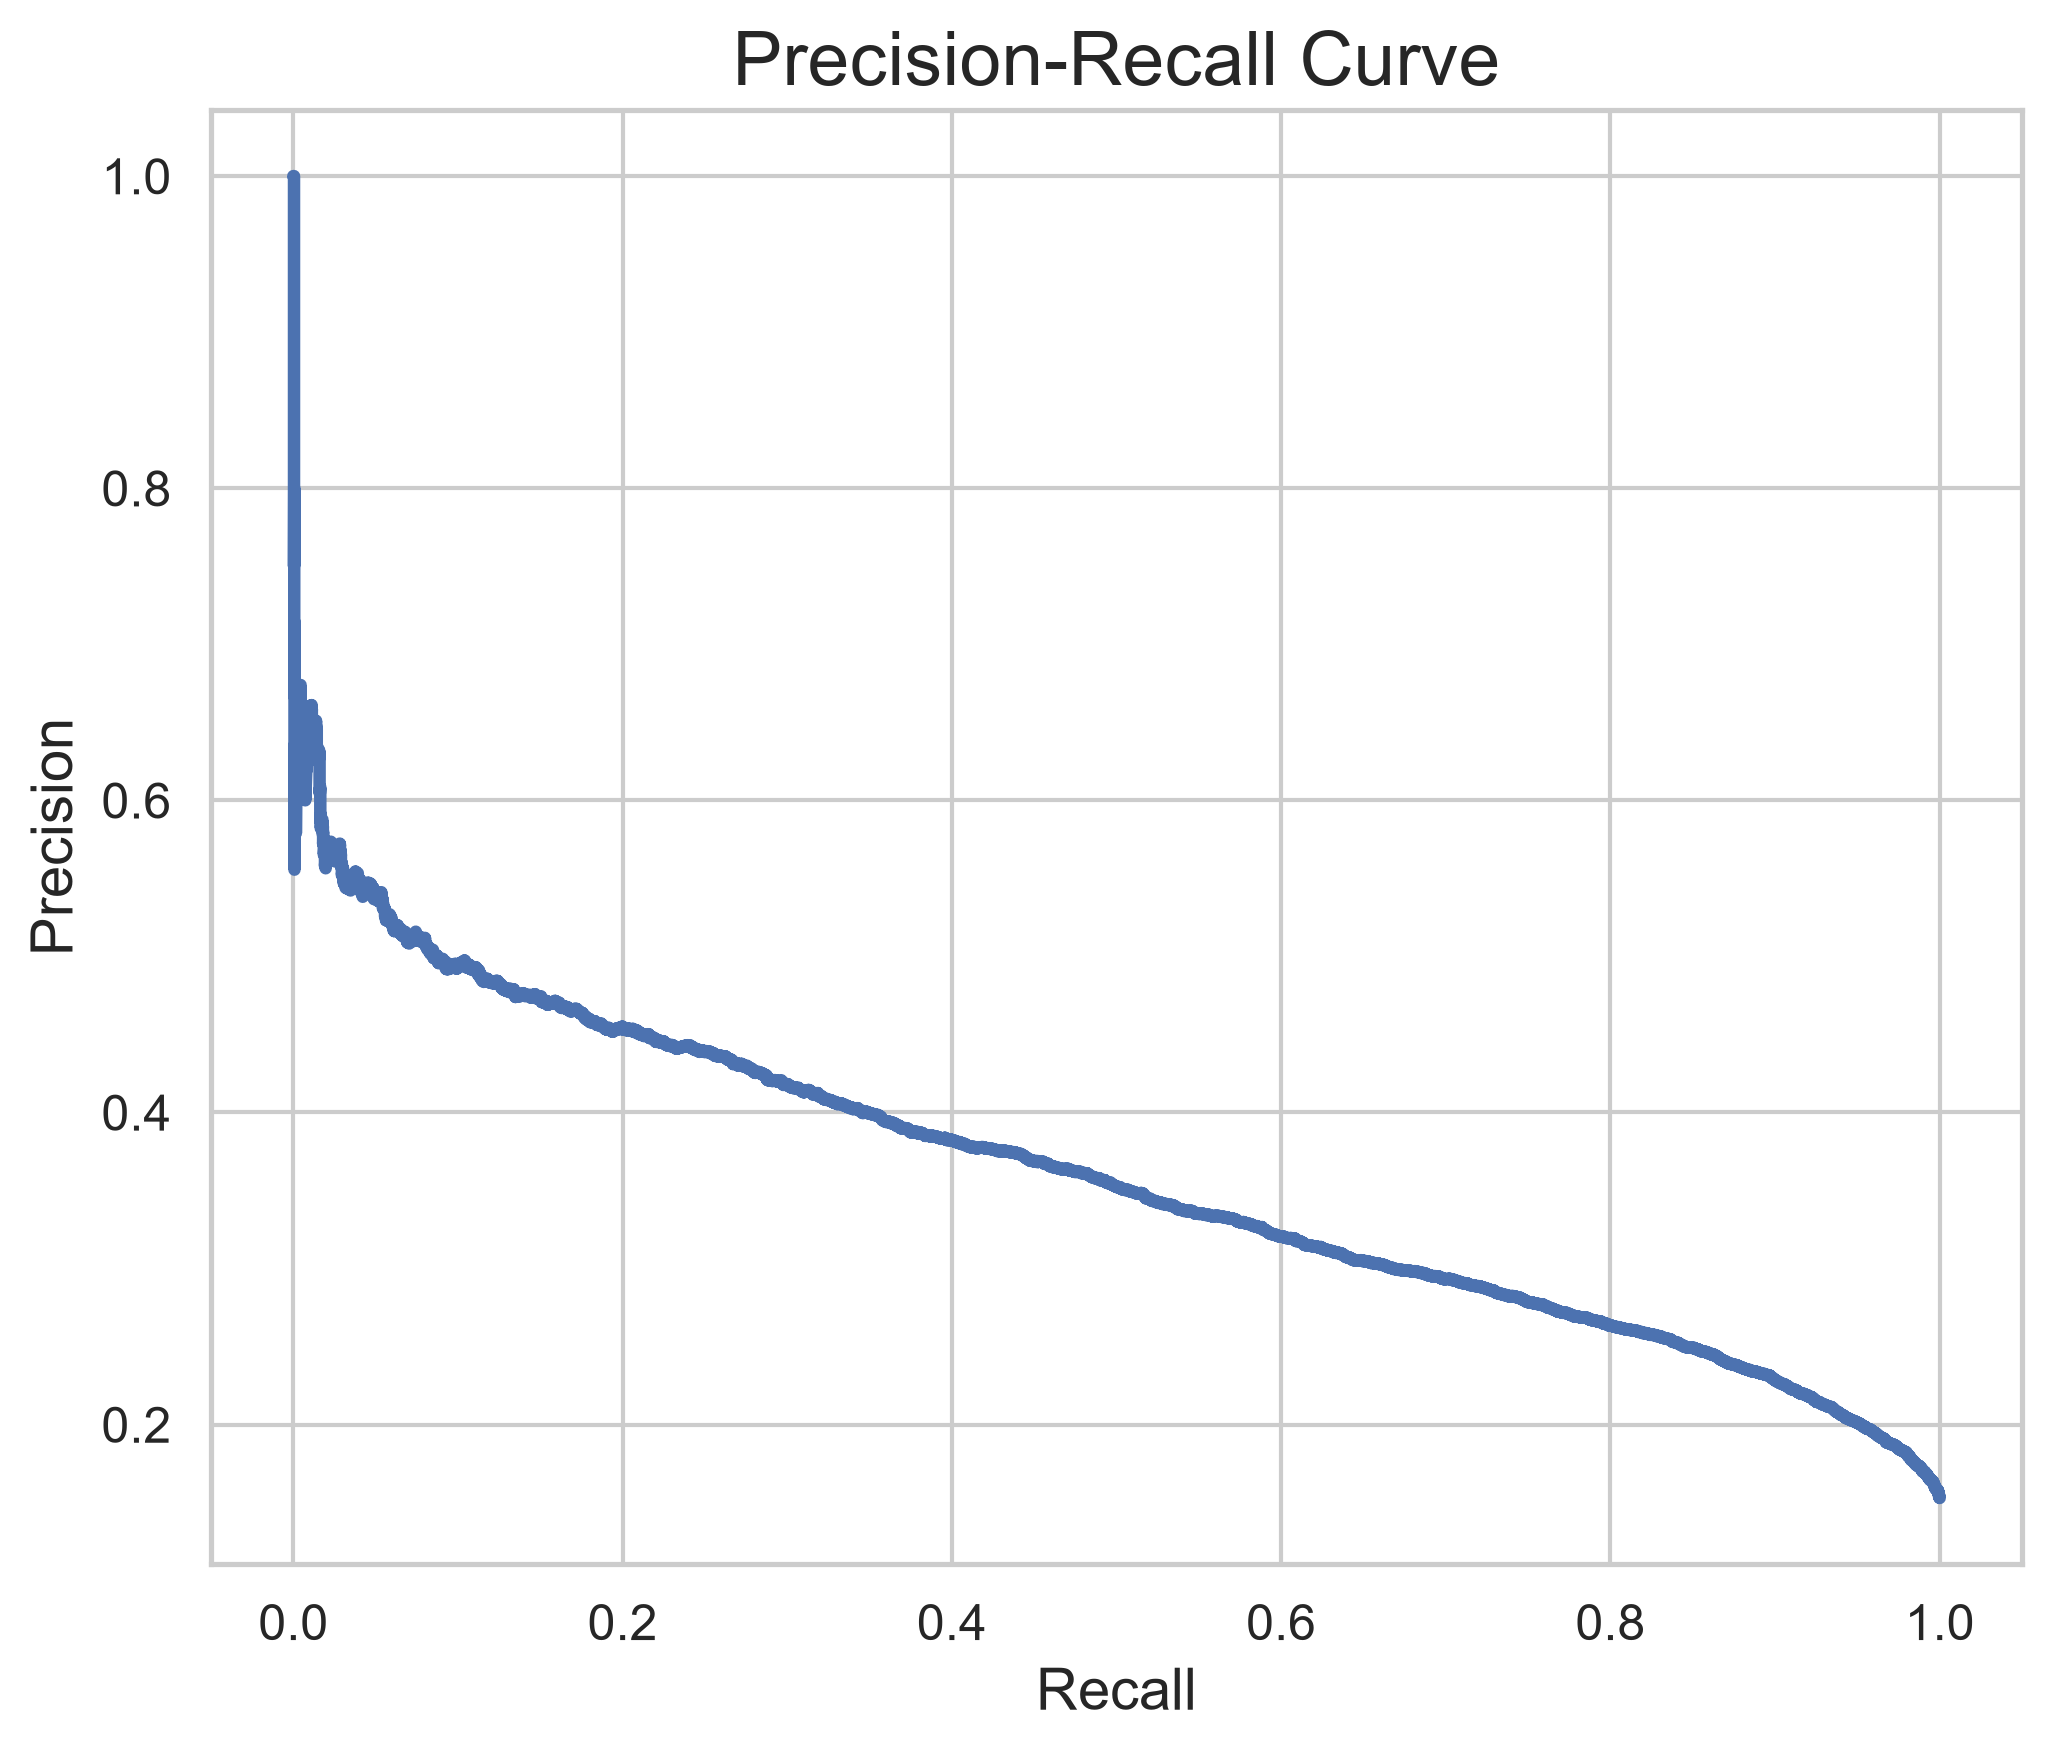

In [22]:
# ===============================================================
# Precision Recall Curve
# ===============================================================

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(

    y_test,

    y_prob

)

fig, ax = plt.subplots(

    figsize=(7,6)

)

ax.plot(

    recall,

    precision,

    color="#4C72B0",

    linewidth=3

)

ax.set_xlabel("Recall")

ax.set_ylabel("Precision")

ax.set_title("Precision-Recall Curve")

plt.tight_layout()

save_figure(

    fig,

    CATBOOST_FIGURES_DIR,

    "precision_recall_curve.png"

)

plt.show()

NameError: name 'save_figure' is not defined

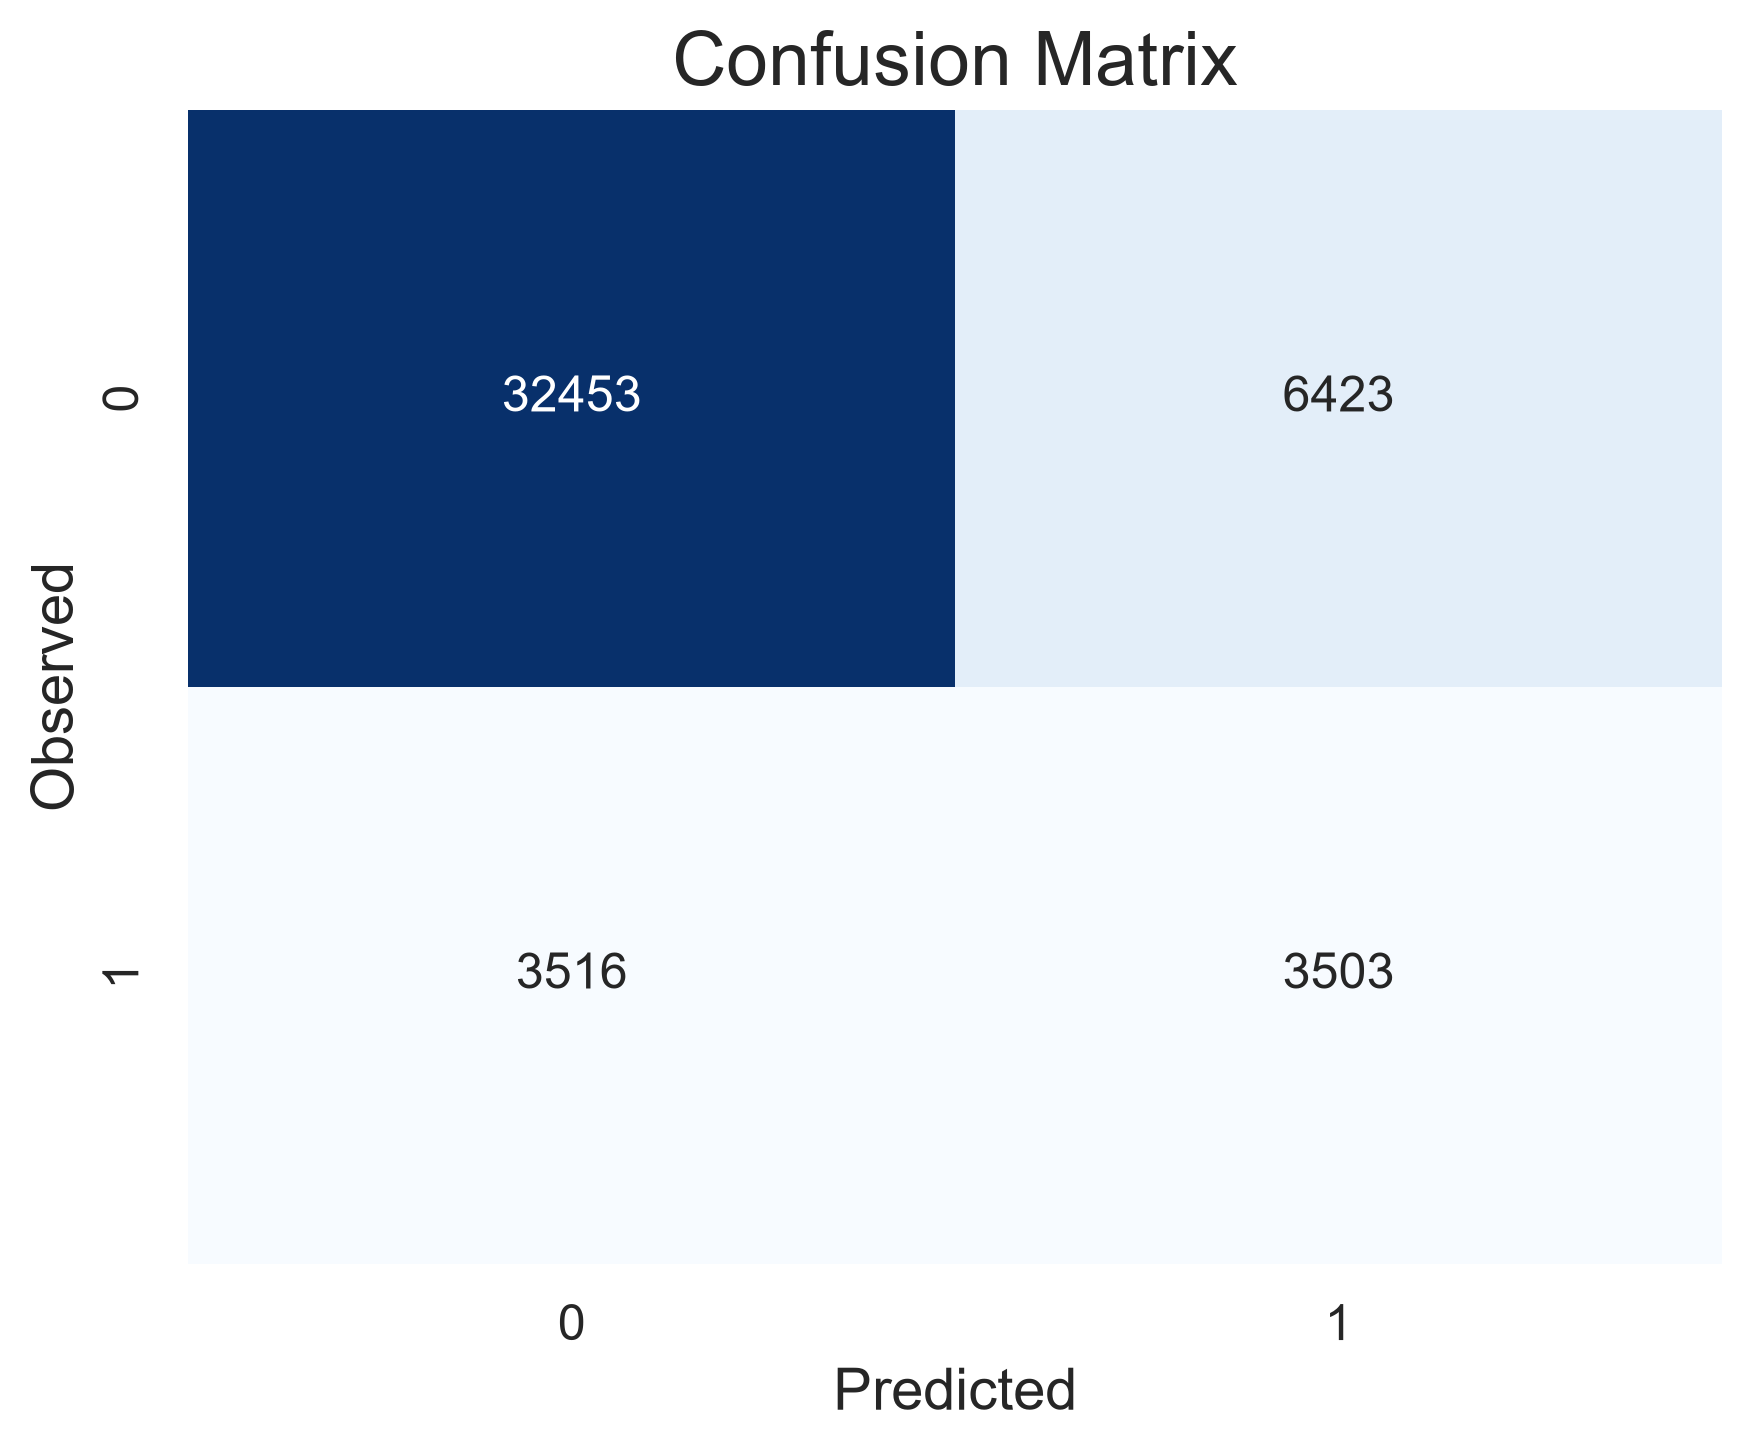

In [23]:
# ===============================================================
# Confusion Matrix
# ===============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)

fig, ax = plt.subplots(

    figsize=(6,5)

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    cbar=False,

    ax=ax

)

ax.set_xlabel("Predicted")

ax.set_ylabel("Observed")

ax.set_title("Confusion Matrix")

plt.tight_layout()

save_figure(

    fig,

    CATBOOST_FIGURES_DIR,

    "confusion_matrix.png"

)

plt.show()

In [24]:
# ===============================================================
# Feature Importance
# ===============================================================

importance_df = (

    pd.DataFrame({

        "Feature":X_train.columns,

        "Importance":cat_model.get_feature_importance()

    })

    .sort_values(

        "Importance",

        ascending=False

    )

)

display(

    importance_df.head(20)

)

importance_df.to_csv(

    CATBOOST_RESULTS_DIR /

    "feature_importance.csv",

    index=False

)

,Feature,Importance
15,Age,17.314024
17,Income,11.743312
12,GenHlth,9.563771
18,BMI_cat,9.280882
16,Education,8.215877
20,PhysHlth_cat,6.323283
19,MentHlth_cat,5.475089
0,HighBP,4.887263
1,HighChol,4.682395
14,Sex,4.148375


NameError: name 'save_figure' is not defined

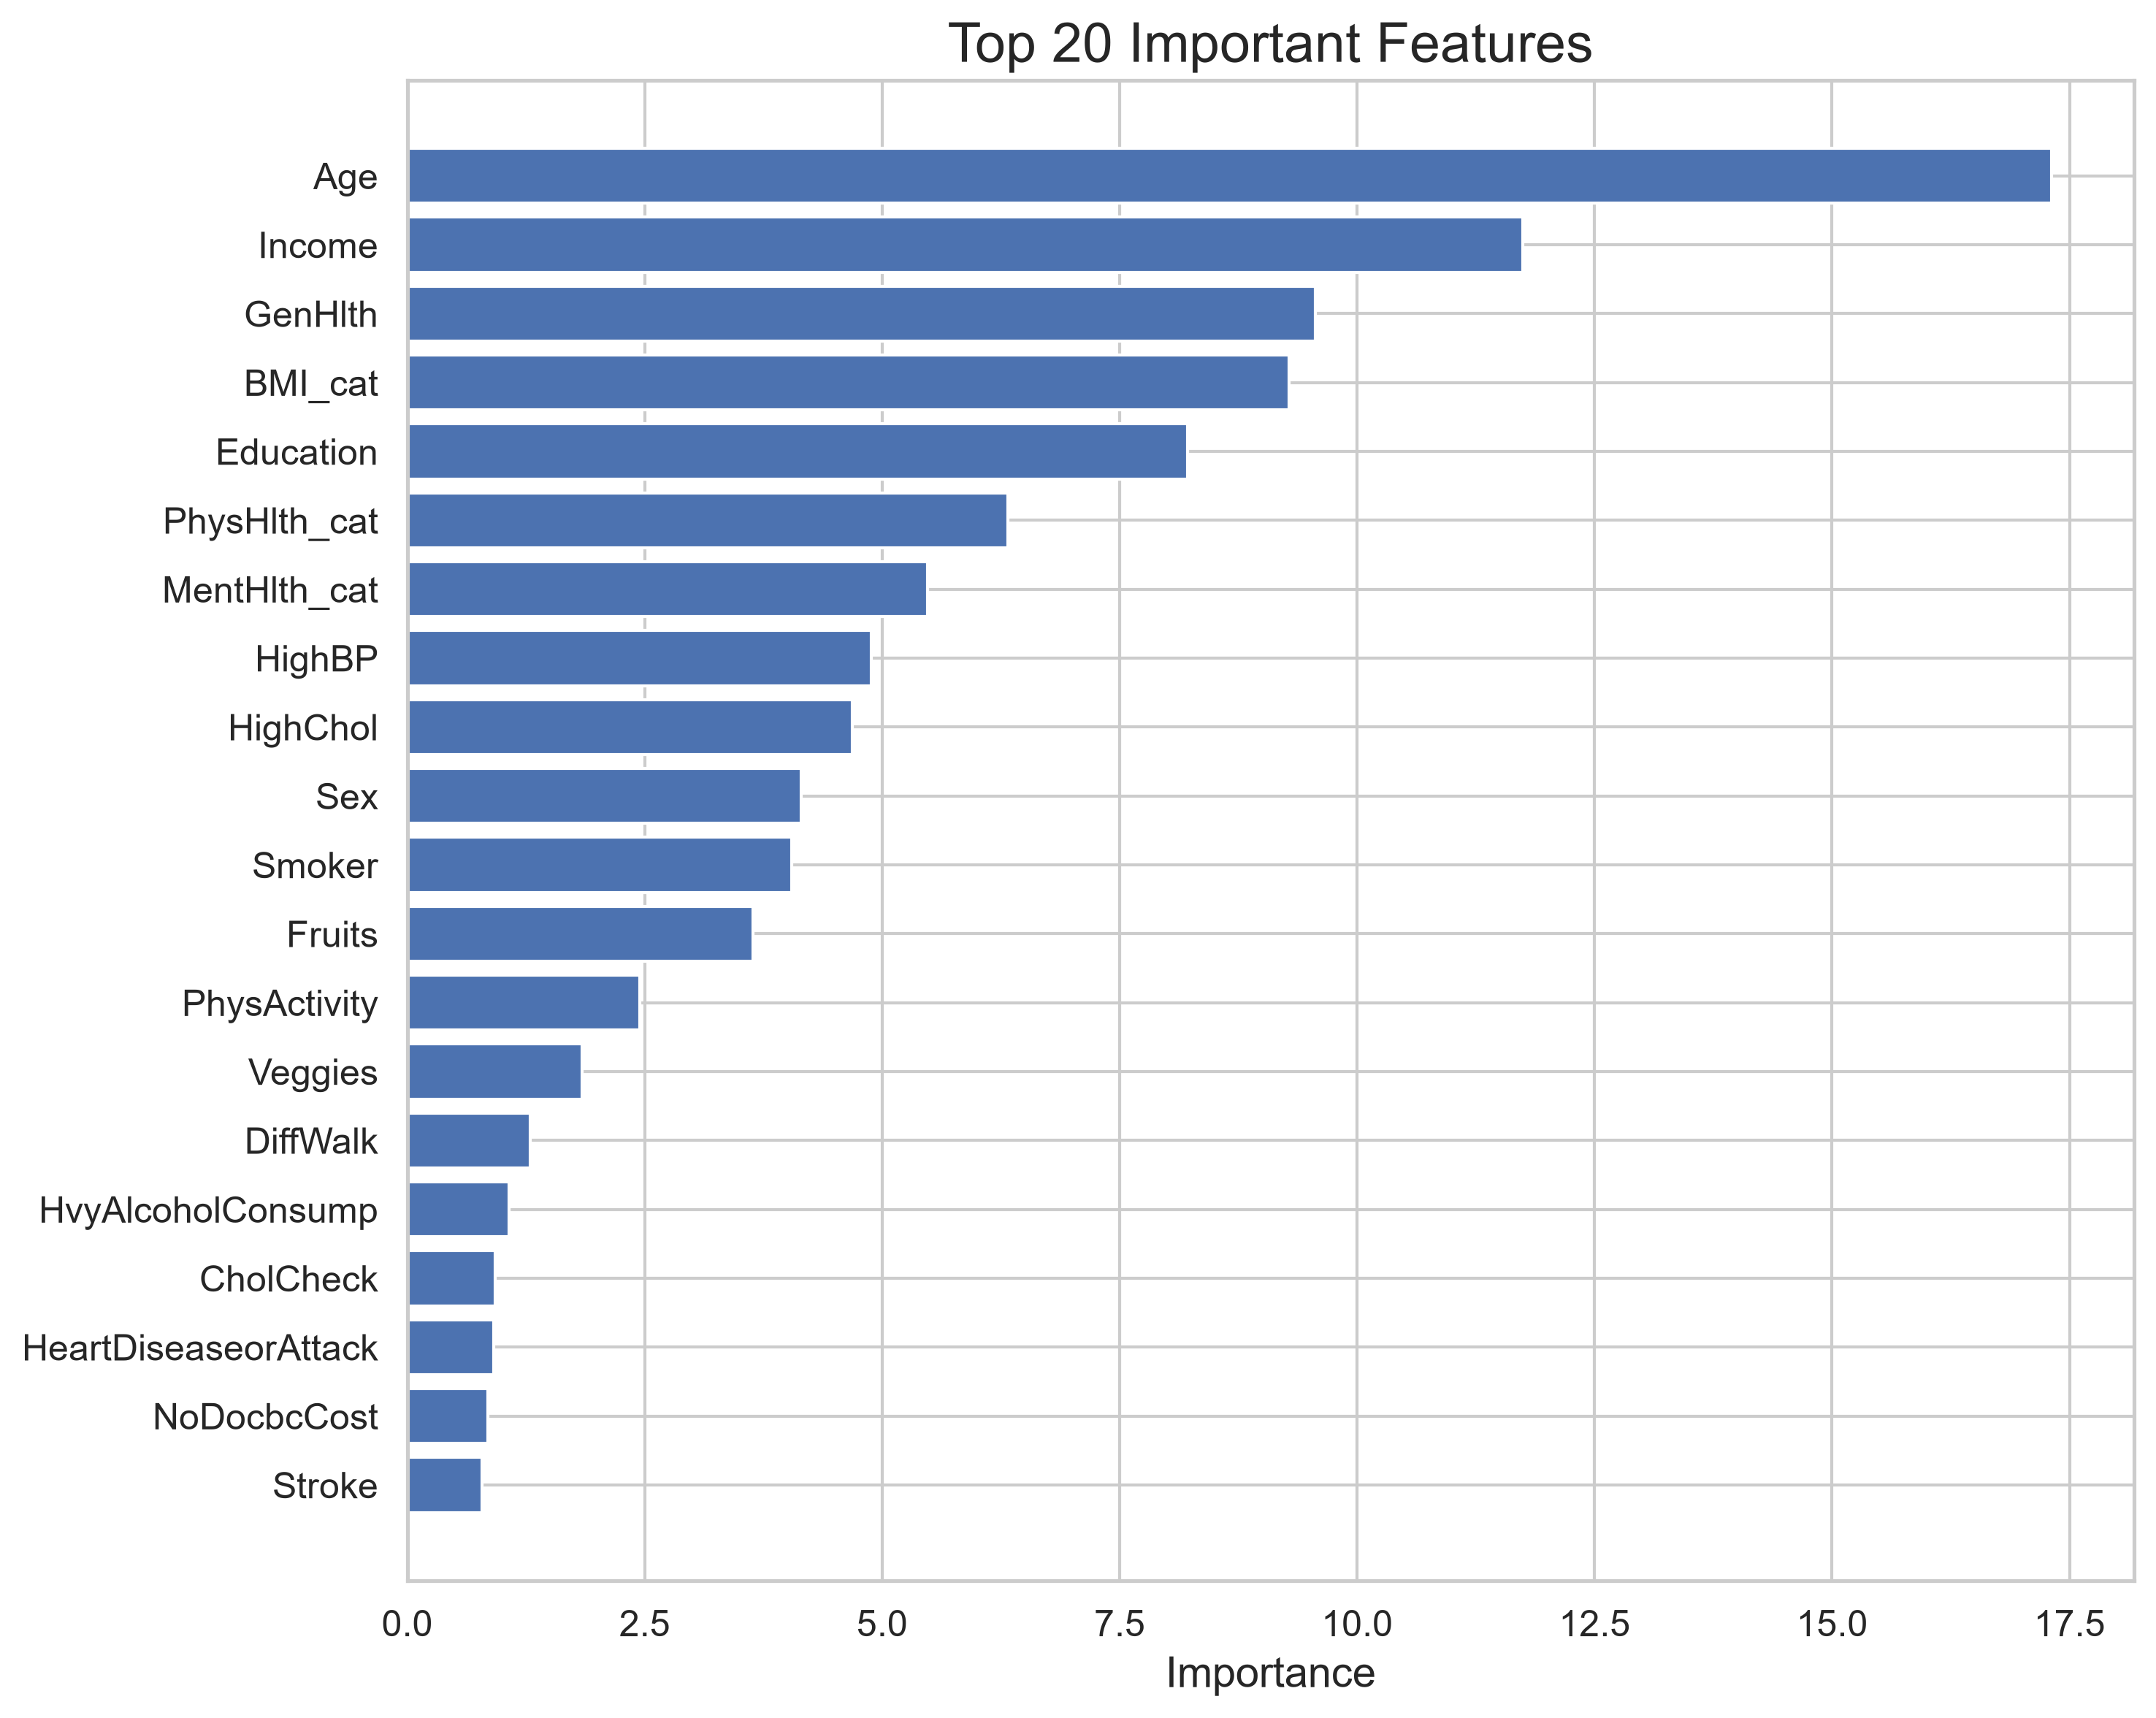

In [25]:
# ===============================================================
# Feature Importance Plot
# ===============================================================

fig, ax = plt.subplots(

    figsize=(10,8)

)

top20 = importance_df.head(20)

ax.barh(

    top20["Feature"][::-1],

    top20["Importance"][::-1],

    color="#4C72B0"

)

ax.set_xlabel("Importance")

ax.set_title("Top 20 Important Features")

plt.tight_layout()

save_figure(

    fig,

    CATBOOST_FIGURES_DIR,

    "feature_importance.png"

)

plt.show()

NameError: name 'save_figure' is not defined

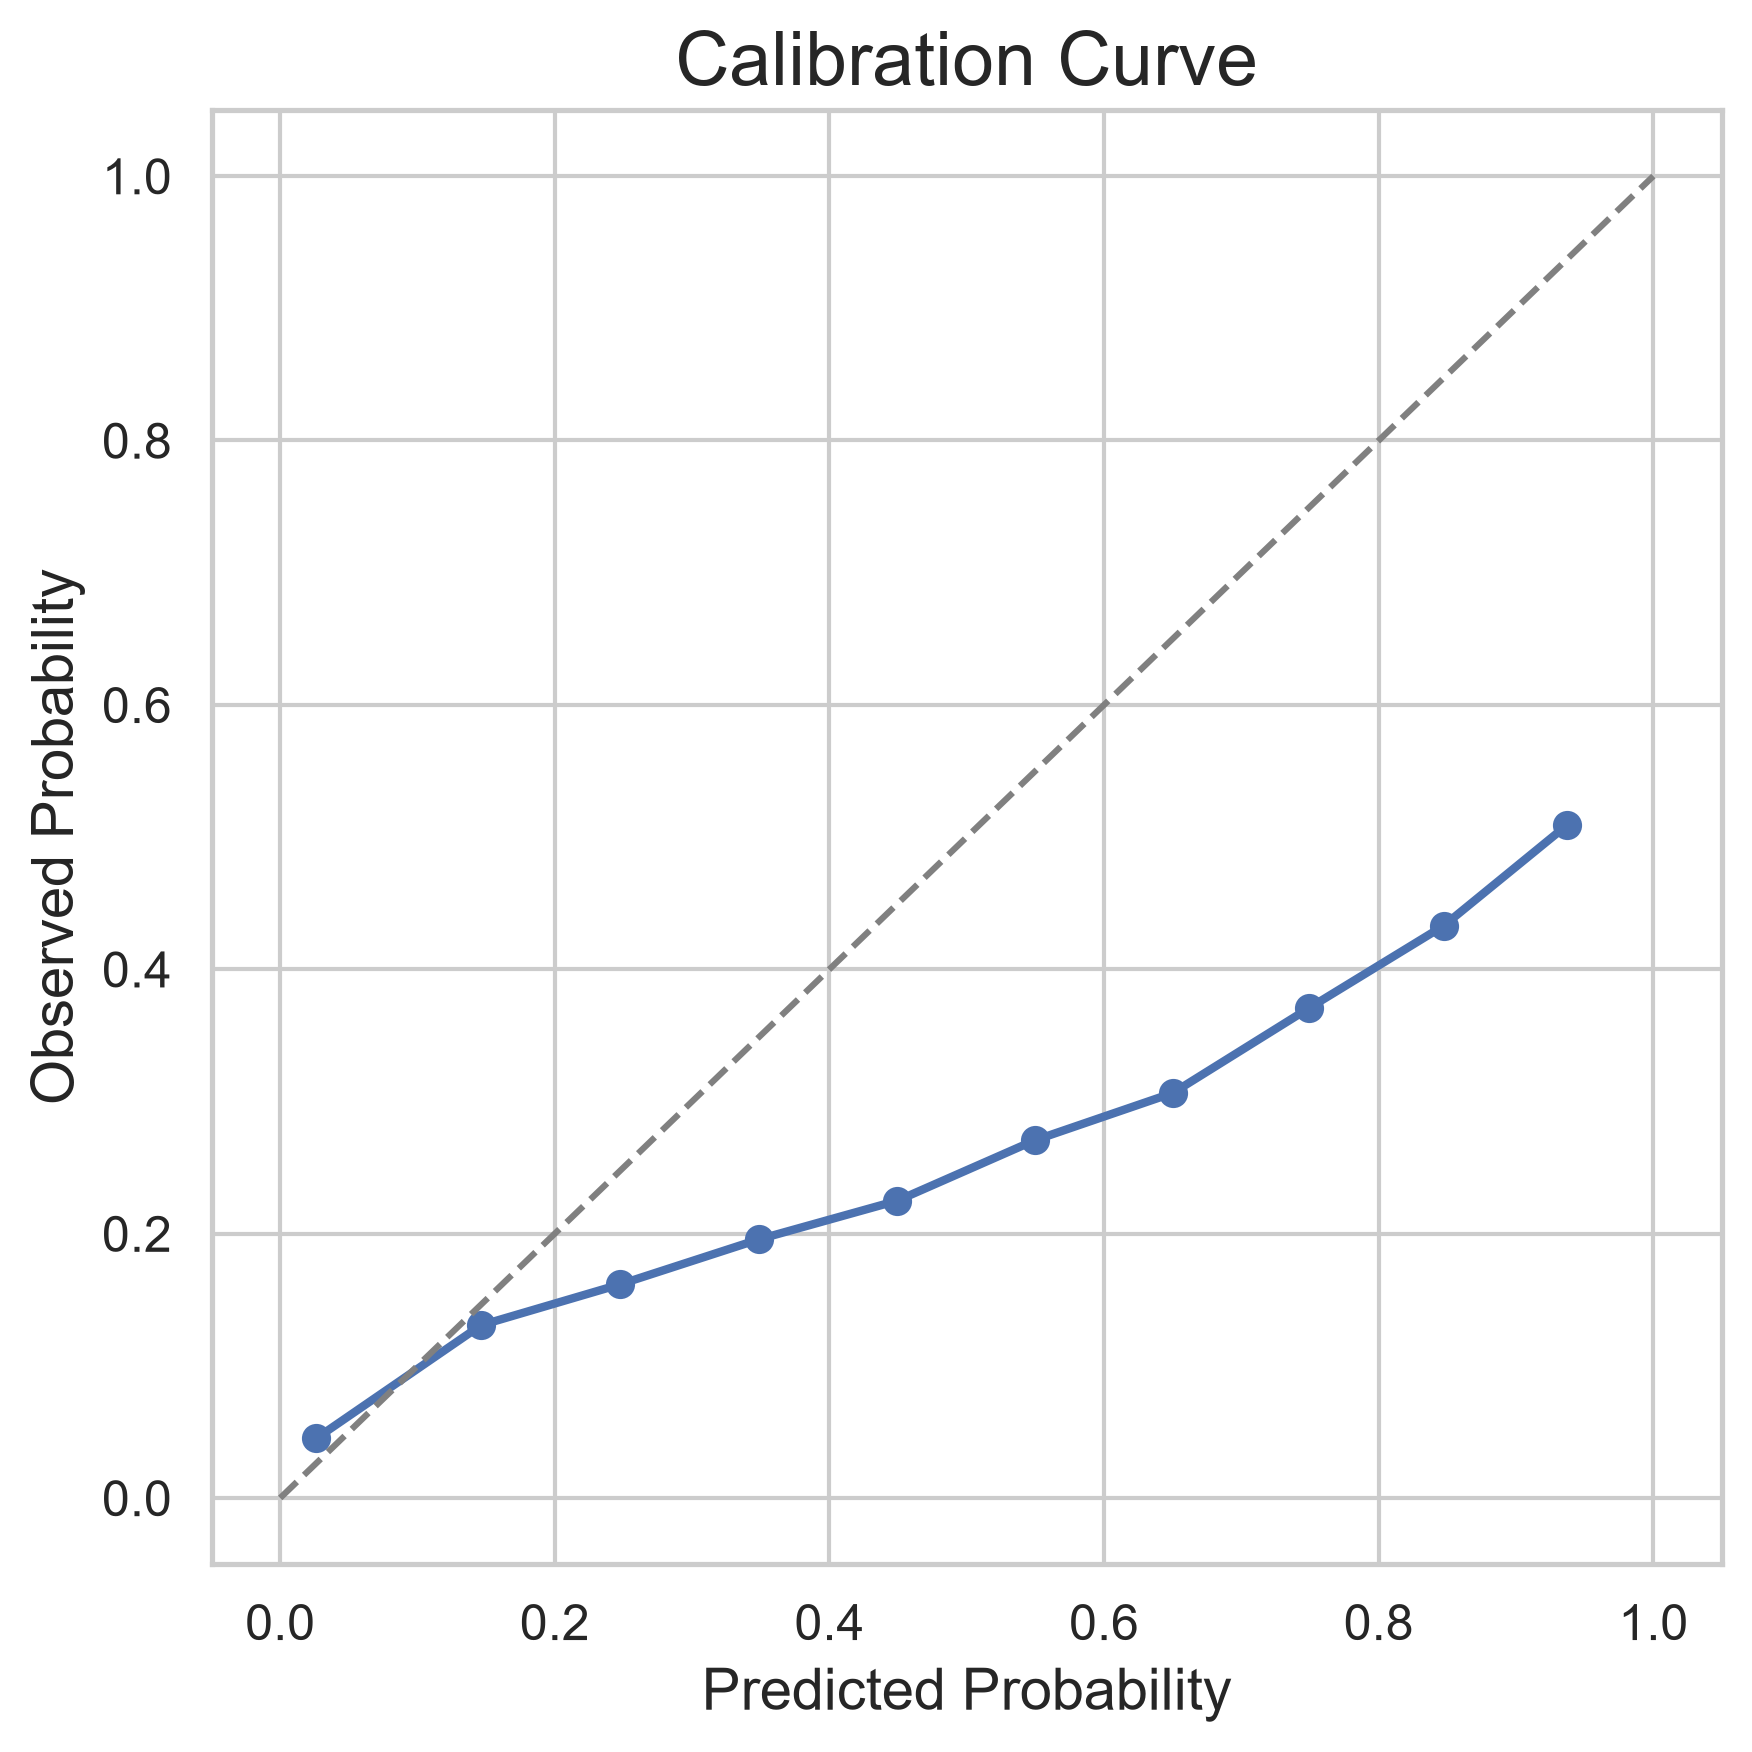

In [26]:
# ===============================================================
# Calibration Curve
# ===============================================================

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(

    y_test,

    y_prob,

    n_bins=10

)

fig, ax = plt.subplots(

    figsize=(6,6)

)

ax.plot(

    prob_pred,

    prob_true,

    marker="o",

    linewidth=2

)

ax.plot(

    [0,1],

    [0,1],

    "--",

    color="grey"

)

ax.set_xlabel("Predicted Probability")

ax.set_ylabel("Observed Probability")

ax.set_title("Calibration Curve")

plt.tight_layout()

save_figure(

    fig,

    CATBOOST_FIGURES_DIR,

    "calibration_curve.png"

)

plt.show()

In [27]:
# ===============================================================
# Notebook Summary
# ===============================================================

print("="*70)

print("Notebook Completed Successfully")

print("="*70)

print()

print(f"Training observations : {X_train.shape[0]}")

print(f"Testing observations  : {X_test.shape[0]}")

print()

print(f"Best CV ROC-AUC : {study.best_value:.4f}")

print()

print(metrics_df)

print()

print("Outputs saved to:")

print(CATBOOST_RESULTS_DIR)

print(CATBOOST_MODEL_DIR)

print(CATBOOST_FIGURES_DIR)

Notebook Completed Successfully

Training observations : 183579
Testing observations  : 45895

Best CV ROC-AUC : 0.8114

                      CatBoost
Accuracy              0.783440
Balanced Accuracy     0.666928
Precision             0.352912
Recall                0.499074
F1 Score              0.413455
ROC AUC               0.768291
Matthews Correlation  0.291868
Cohen Kappa           0.285422
Brier Score           0.146959

Outputs saved to:
c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\results\catboost
c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\models\catboost
c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\figures\catboost
